# Port loading gaps — berth idle time vs export pace

Replicates the Kpler-style **breaks between loadings** chart for any crude (or other) export port.

**Top panel:** idle gaps between berthing (`Port Calls` start/end), daily idle hours (7d MA), arrival markers.  
**Bottom panel:** export flows (`Flows` endpoint, 7d MA).

Change `LOCATION` below to switch ports — e.g. `Yanbu`, `Ruwais`, `Ras Tanura`.

**Kernel:** repo `.venv` (needs `kpler.sdk`). Credentials from `vessel_crossing/.env`.

In [1]:
from __future__ import annotations

import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Allow imports from this folder when running in Jupyter.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "port_loading_gaps":
    NOTEBOOK_DIR = NOTEBOOK_DIR / "vessel_crossing" / "port_loading_gaps"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from loading_gaps import (
    LoadingGapConfig,
    LocationSpec,
    analyze_loading_gaps,
    fetch_export_flows,
    fetch_port_calls,
    parse_env,
    plot_loading_gaps,
)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

BASE = NOTEBOOK_DIR.parent
ENV_PATH = BASE / ".env"

# --- change these to analyze another port ---
LOCATION = LocationSpec("Yanbu", kind="zone")  # or LocationSpec("Ras Tanura", kind="zone")
PRODUCT = "crude"
START = date(2026, 2, 1)
END = date(2026, 8, 1)
FLOW_UNIT = "kbd"  # kb/d for crude exports
MA_DAYS = 7

# Optional vertical event markers: (date, label)
EVENTS: list[tuple[date, str]] = [
    # (date(2026, 6, 13), "example event"),
]

CONFIG = LoadingGapConfig(
    location=LOCATION,
    product=PRODUCT,
    start_date=START,
    end_date=END,
    flow_unit=FLOW_UNIT,
    ma_days=MA_DAYS,
    with_forecast=False,
    only_realized_flows=True,
)

CONFIG

LoadingGapConfig(location=LocationSpec(name='Yanbu', kind='zone'), product='crude', start_date=datetime.date(2026, 2, 1), end_date=datetime.date(2026, 8, 1), flow_unit='kbd', with_forecast=False, only_realized_flows=True, ma_days=7, min_gap_hours=1.0)

In [2]:
cred = parse_env(ENV_PATH)
assert cred.get("KPLER_EMAIL") and cred.get("KPLER_PASSWORD"), (
    f"Missing KPLER_EMAIL / KPLER_PASSWORD in {ENV_PATH}"
)

port_calls = fetch_port_calls(
    CONFIG,
    email=cred["KPLER_EMAIL"],
    password=cred["KPLER_PASSWORD"],
)
export_flows = fetch_export_flows(
    CONFIG,
    email=cred["KPLER_EMAIL"],
    password=cred["KPLER_PASSWORD"],
)

print(f"Port calls with berthing times: {len(port_calls):,}")
if not port_calls.empty:
    print(
        f"  {port_calls['start'].min():%Y-%m-%d} → {port_calls['end'].max():%Y-%m-%d}"
    )
    print("Installations:")
    print(port_calls["installation_name"].value_counts().head(8).to_string())

print(f"\nExport flow days: {len(export_flows):,}")
if not export_flows.empty:
    print(f"  avg {export_flows.mean():,.0f} {FLOW_UNIT}")

port_calls.tail(15)

c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\.venv\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Port calls with berthing times: 424
  2026-02-01 → 2026-07-30
Installations:
installation_name
Yanbu Crude    226
Muajjiz        198

Export flow days: 182
  avg 3,328 kbd


,vessel_name,vessel_imo,vessel_type,installation_name,start,end,closest_ancestor_group,cargo_origin_barrels_split_by_product,is_sts,is_reexport,multiple_forecasted_zones
409,Karachi,9903413,LR2,Yanbu Crude,2026-07-22 19:39:00,2026-07-23 23:03:00,Crude/Co,433789,False,False,NaN
410,Dht Gazelle,1055155,VLCC,Yanbu Crude,2026-07-23 00:00:00,2026-07-25 00:00:00,Crude/Co,1081929,False,False,NaN
411,Desh Vaibhav,9297498,VLCC,Yanbu Crude,2026-07-23 05:57:00,2026-07-26 00:00:00,Crude/Co,2111483,False,False,NaN
412,Dht Puma,9728837,VLCC,Yanbu Crude,2026-07-23 08:00:00,2026-07-24 00:00:00,Crude/Co,2065001,False,False,NaN
413,New Pearl,9468322,VLCC,Yanbu Crude,2026-07-24 00:00:00,2026-07-25 00:00:00,Crude/Co,2047088,False,False,NaN
414,Amzan,9693745,VLCC,Muajjiz,2026-07-25 00:00:00,2026-07-27 00:00:00,Crude/Co,2141428,False,False,NaN
415,New Discovery,9269075,LR3,Yanbu Crude,2026-07-25 00:00:00,2026-07-26 00:00:00,Crude/Co,1040403,False,False,NaN
416,Front Empire,9788332,VLCC,Muajjiz,2026-07-25 00:00:00,2026-07-26 00:00:00,Crude/Co,1200001,False,False,NaN
417,Niban,9484716,VLCC,Muajjiz,2026-07-25 00:00:00,2026-07-27 00:00:00,Crude/Co,2000002,False,False,NaN
418,Farhah,9484742,VLCC,Muajjiz,2026-07-26 00:00:00,2026-07-28 00:00:00,Crude/Co,2000002,False,False,NaN


Idle gaps (>=1.0h): 20
  median 7.0h | max 72.0h | total 276h

Daily idle hours (7d MA): latest 10.3 h/day


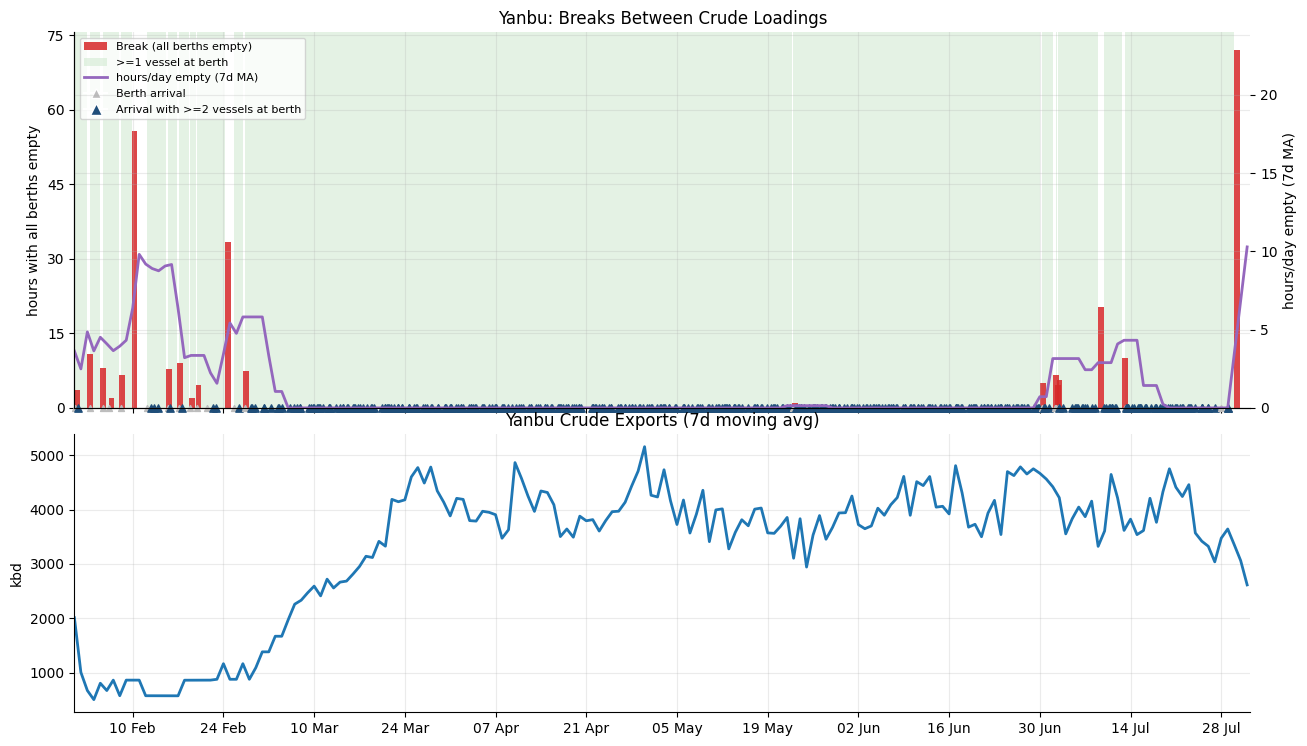

In [3]:
analysis = analyze_loading_gaps(port_calls, CONFIG)

gaps = analysis["gaps"]
print(f"Idle gaps (>={CONFIG.min_gap_hours}h): {len(gaps)}")
if gaps:
    gap_hours = pd.Series([g.hours for g in gaps])
    print(
        f"  median {gap_hours.median():.1f}h | max {gap_hours.max():.1f}h | "
        f"total {gap_hours.sum():.0f}h"
    )

idle_ma = analysis["daily_idle_ma"]
if not idle_ma.empty:
    print(f"\nDaily idle hours ({MA_DAYS}d MA): latest {idle_ma.iloc[-1]:.1f} h/day")

fig = plot_loading_gaps(CONFIG, analysis, export_flows, events=EVENTS or None)
plt.show()

## Switching ports

Edit the config cell:

```python
LOCATION = LocationSpec("Ruwais", kind="zone")
# LOCATION = LocationSpec("Ras Tanura", kind="zone")
# LOCATION = LocationSpec("Some Terminal", kind="installation")
```

Use `kind="installation"` when you want a single berth/terminal instead of the whole port zone.